# tactical-asset-allocation-lstm

**Author:** Sana Ur Rehman  
**Profession:** Data Scientist  
**Created:** 2026  

---

## License

This project is licensed under the **MIT License**. 

You are free to use, modify, distribute, and build upon this work for both commercial and non-commercial purposes, provided you give appropriate **credit** to the original author. For the full legal text and conditions, please refer to the `LICENSE` file included in this project's repository.

---

## Citation

If you reference or build upon this project, please provide appropriate credit.

For formal citation information, please see the project's `README.md` and `CITATION.cff` files.

# Step 1: Data gathering + EDA

In [14]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm

import yfinance as yf


Parameters (tickers, dates, splits)

In [15]:
TICKERS = {
    "Equity (SPY)": "SPY",
    "Long Treasuries (TLT)": "TLT",
    "Short Treasuries (SHY)": "SHY",
    "Gold (GLD)": "GLD",
    "Oil (DBO)": "DBO"
}

# Assignment requires this as the TEST sample window:
TEST_START = "2018-01-01"
TEST_END   = "2022-12-30"

# You have discretion for train/val; choose something reasonable & reproducible.
# Here: train = 2010-01-01..2016-12-31, val = 2017-01-01..2017-12-31 (if data exists)
TRAIN_START = "2010-01-01"
TRAIN_END   = "2016-12-31"
VAL_START   = "2017-01-01"
VAL_END     = "2017-12-31"

# Forecast horizon (business days)
H = 25

Download daily data (Adj Close)

In [16]:
def download_adj_close_robust(tickers_dict, start, end):
    """
    tickers_dict: {"Equity (SPY)": "SPY", ...}
    Returns a DataFrame with columns labeled by the asset-class keys,
    guaranteed to map correctly to the Yahoo tickers.
    """
    tickers_list = list(tickers_dict.values())
    raw = yf.download(
        tickers=tickers_list,
        start=start,
        end=end,
        interval="1d",
        auto_adjust=False,
        progress=False,
        group_by="column"
    )

    # Get Adj Close or Close matrix with columns as ticker symbols
    if isinstance(raw.columns, pd.MultiIndex):
        # Typical: columns like ('Adj Close','SPY'), ...
        if ("Adj Close" in raw.columns.get_level_values(0)):
            px = raw["Adj Close"].copy()
        else:
            px = raw["Close"].copy()
    else:
        # Single ticker case fallback (not expected here)
        px = raw.copy()

    # px columns should be ticker symbols (SPY, TLT,...)
    # Build reverse mapping: {"SPY":"Equity (SPY)", ...}
    rev = {v: k for k, v in tickers_dict.items()}

    # Keep only the tickers we requested, in case extra appear
    px = px.loc[:, [c for c in px.columns if c in rev]]

    # Rename tickers -> asset-class labels
    px = px.rename(columns=rev)

    # Enforce consistent column order (same as your dict keys)
    px = px[[k for k in tickers_dict.keys() if k in px.columns]]

    return px.dropna(how="all")

In [17]:
adj_close = download_adj_close_robust(
    TICKERS,
    start=TRAIN_START,
    end=pd.to_datetime(TEST_END) + pd.Timedelta(days=1)
)

adj_close.tail(), adj_close.shape

(Ticker      Equity (SPY)  Long Treasuries (TLT)  Short Treasuries (SHY)  \
 Date                                                                      
 2022-12-23    368.078094              90.447388               72.820450   
 2022-12-27    366.626587              88.658951               72.721947   
 2022-12-28    362.070190              88.136604               72.721947   
 2022-12-29    368.587585              89.137047               72.775635   
 2022-12-30    367.616730              88.145454               72.686134   
 
 Ticker      Gold (GLD)  Oil (DBO)  
 Date                               
 2022-12-23  167.259995  13.222277  
 2022-12-27  168.669998  13.319239  
 2022-12-28  167.910004  13.178202  
 2022-12-29  168.850006  13.116498  
 2022-12-30  169.639999  13.407389  ,
 (3272, 5))

In [18]:
last = adj_close.dropna().iloc[-1].sort_values()
display(last)

assert last["Equity (SPY)"] > 50, "SPY looks too small — mapping likely wrong."
assert last["Gold (GLD)"] > 50, "GLD looks too small — mapping likely wrong."
assert last["Short Treasuries (SHY)"] > 10, "SHY looks too small — mapping likely wrong."

Ticker
Oil (DBO)                  13.407389
Short Treasuries (SHY)     72.686134
Long Treasuries (TLT)      88.145454
Gold (GLD)                169.639999
Equity (SPY)              367.616730
Name: 2022-12-30 00:00:00, dtype: float64

Build returns + forward 25-day returns (prediction target

In [19]:
# Daily log returns (more additive, common in finance)
ret = np.log(adj_close / adj_close.shift(1)).dropna()

# 25-day ahead log return: r_{t->t+H} = log(P_{t+H}/P_t)
fwd_25d = np.log(adj_close.shift(-H) / adj_close).loc[ret.index]  # align with ret index
fwd_25d = fwd_25d.dropna()

# Align features/targets so they share the same index
common_idx = ret.index.intersection(fwd_25d.index)
ret = ret.loc[common_idx]
fwd_25d = fwd_25d.loc[common_idx]

ret.shape, fwd_25d.shape

((3246, 5), (3246, 5))

Train/Validation/Test split (time-based)

In [20]:
def slice_period(df, start, end):
    return df.loc[(df.index >= pd.to_datetime(start)) & (df.index <= pd.to_datetime(end))].copy()

splits = {
    "train": (TRAIN_START, TRAIN_END),
    "val":   (VAL_START, VAL_END),
    "test":  (TEST_START, TEST_END)
}

ret_split = {k: slice_period(ret, *v) for k, v in splits.items()}
y_split   = {k: slice_period(fwd_25d, *v) for k, v in splits.items()}

{k: (ret_split[k].shape, y_split[k].shape) for k in splits}


{'train': ((1761, 5), (1761, 5)),
 'val': ((251, 5), (251, 5)),
 'test': ((1234, 5), (1234, 5))}

In [21]:
import os
os.makedirs("data", exist_ok=True)

adj_close.to_csv("data/adj_close.csv")
ret.to_csv("data/daily_log_returns.csv")
fwd_25d.to_csv("data/fwd_25d_log_returns.csv")

for k in splits:
    ret_split[k].to_csv(f"data/returns_{k}.csv")
    y_split[k].to_csv(f"data/target_{k}.csv")

print("Saved CSVs under ./data/")


Saved CSVs under ./data/


EDA: Summary statistics tables

In [22]:
def summary_stats(df):
    out = pd.DataFrame({
        "mean": df.mean(),
        "std": df.std(),
        "skew": df.skew(),
        "kurtosis": df.kurtosis(),
        "min": df.min(),
        "max": df.max()
    })
    return out

stats_daily = summary_stats(ret)
stats_daily

# Annualized approximations (log returns):
TRADING_DAYS = 252
annualized = pd.DataFrame({
    "ann_mean": ret.mean() * TRADING_DAYS,
    "ann_vol":  ret.std() * np.sqrt(TRADING_DAYS),
    "sharpe_like_(rf=0)": (ret.mean() * TRADING_DAYS) / (ret.std() * np.sqrt(TRADING_DAYS))
})
annualized


,ann_mean,ann_vol,sharpe_like_(rf=0)
Ticker,,,
Equity (SPY),0.117261,0.176461,0.664513
Long Treasuries (TLT),0.036916,0.150362,0.245516
Short Treasuries (SHY),0.006716,0.010905,0.615871
Gold (GLD),0.030710,0.157255,0.195290
Oil (DBO),-0.045428,0.305980,-0.148468


EDA: Price series + cumulative performance

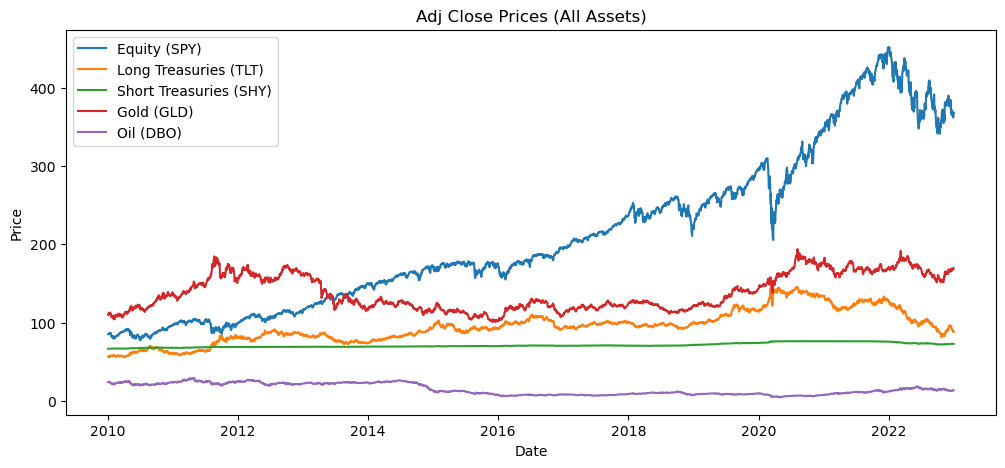

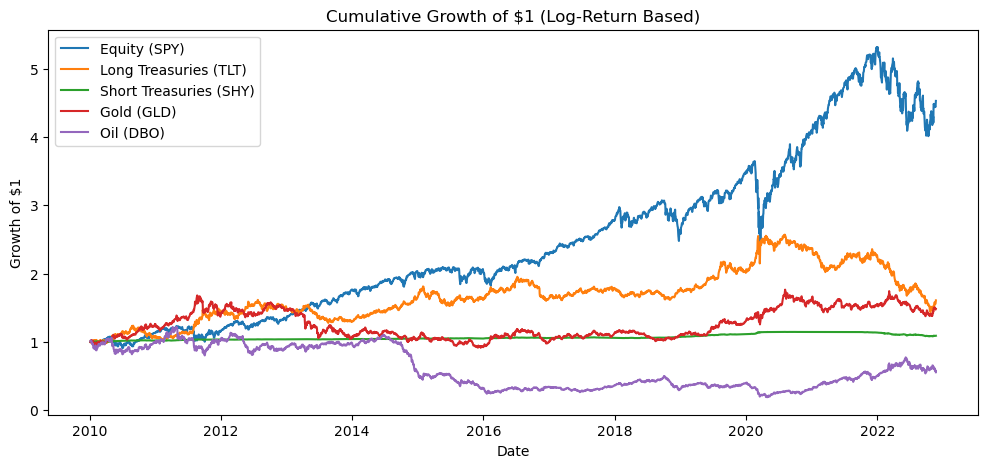

In [23]:
plt.figure(figsize=(12,5))
for col in adj_close.columns:
    plt.plot(adj_close.index, adj_close[col], label=col)
plt.title("Adj Close Prices (All Assets)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

cum = (ret).cumsum().apply(np.exp)  # exp(sum(log returns)) = cumulative gross return

plt.figure(figsize=(12,5))
for col in cum.columns:
    plt.plot(cum.index, cum[col], label=col)
plt.title("Cumulative Growth of $1 (Log-Return Based)")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

EDA: Distributions (histograms) + QQ plots

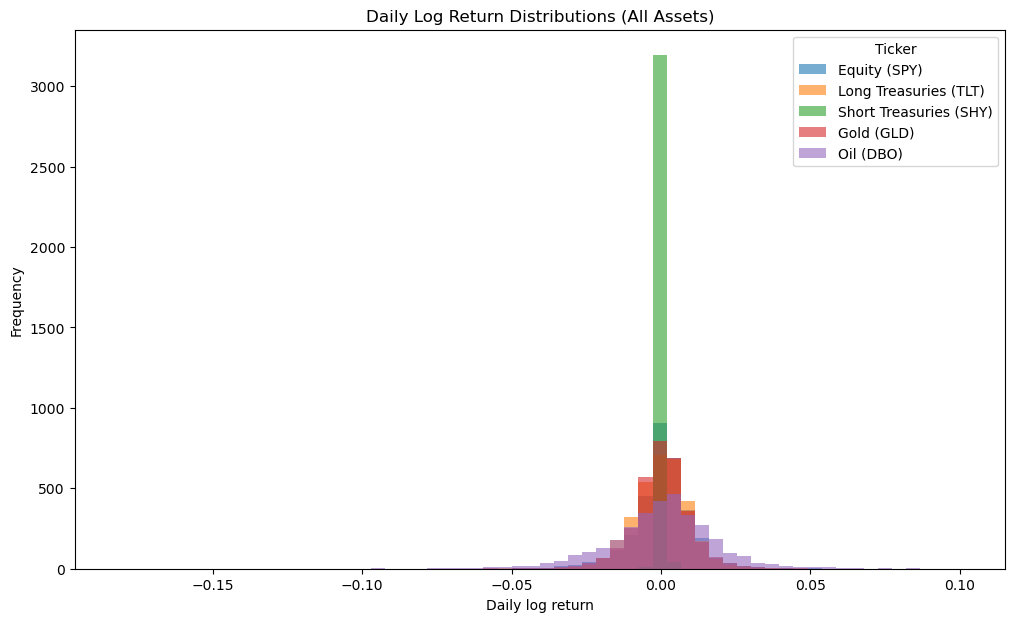

<Figure size 500x500 with 0 Axes>

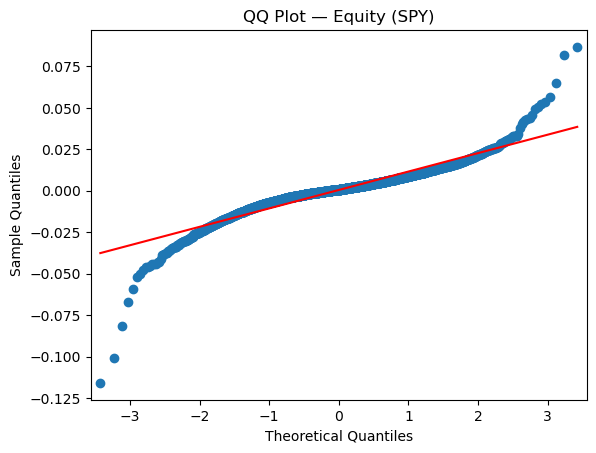

<Figure size 500x500 with 0 Axes>

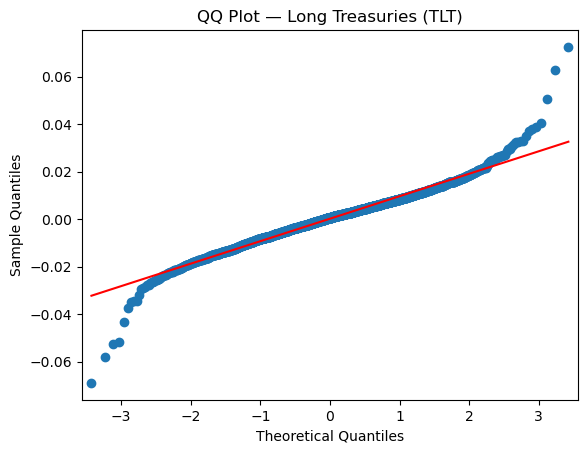

<Figure size 500x500 with 0 Axes>

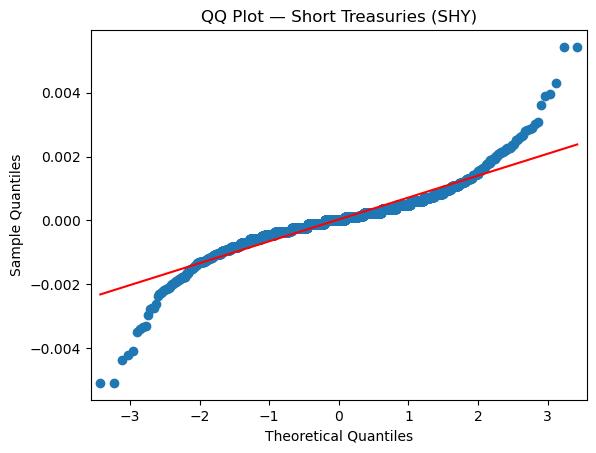

<Figure size 500x500 with 0 Axes>

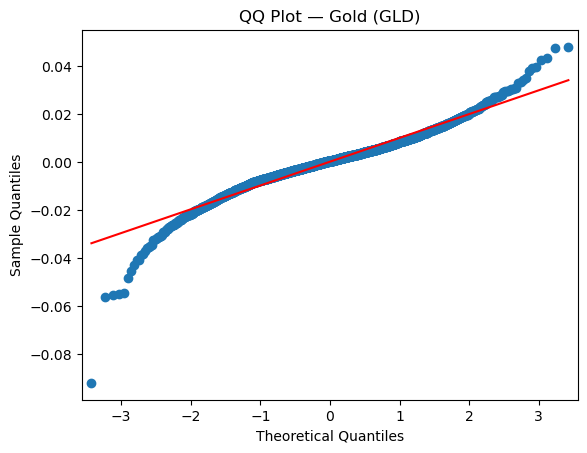

<Figure size 500x500 with 0 Axes>

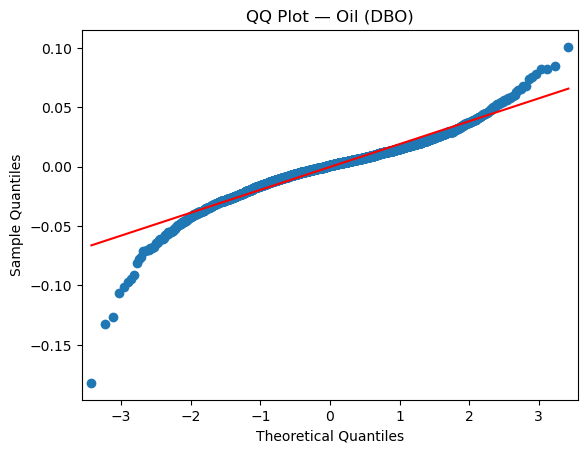

In [24]:
# Histograms
ret.plot(kind="hist", bins=60, alpha=0.6, figsize=(12,7))
plt.title("Daily Log Return Distributions (All Assets)")
plt.xlabel("Daily log return")
plt.show()

# QQ plots per asset
for col in ret.columns:
    plt.figure(figsize=(5,5))
    sm.qqplot(ret[col].dropna(), line="s")
    plt.title(f"QQ Plot — {col}")
    plt.show()

EDA: Rolling volatility (risk dynamics)

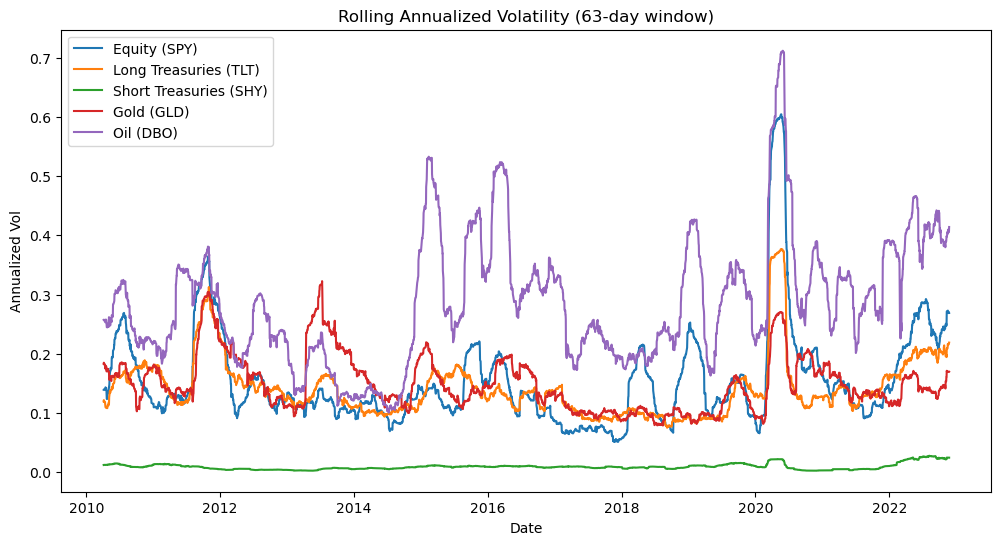

In [25]:
roll_vol = ret.rolling(63).std() * np.sqrt(252)  # ~3 months rolling annualized vol

plt.figure(figsize=(12,6))
for col in roll_vol.columns:
    plt.plot(roll_vol.index, roll_vol[col], label=col)
plt.title("Rolling Annualized Volatility (63-day window)")
plt.xlabel("Date")
plt.ylabel("Annualized Vol")
plt.legend()
plt.show()

EDA: Joint distributions (correlation & covariance)

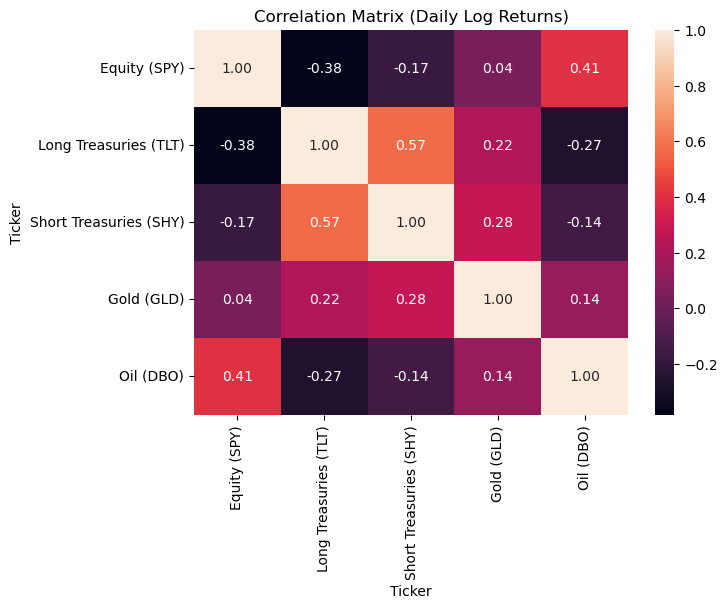

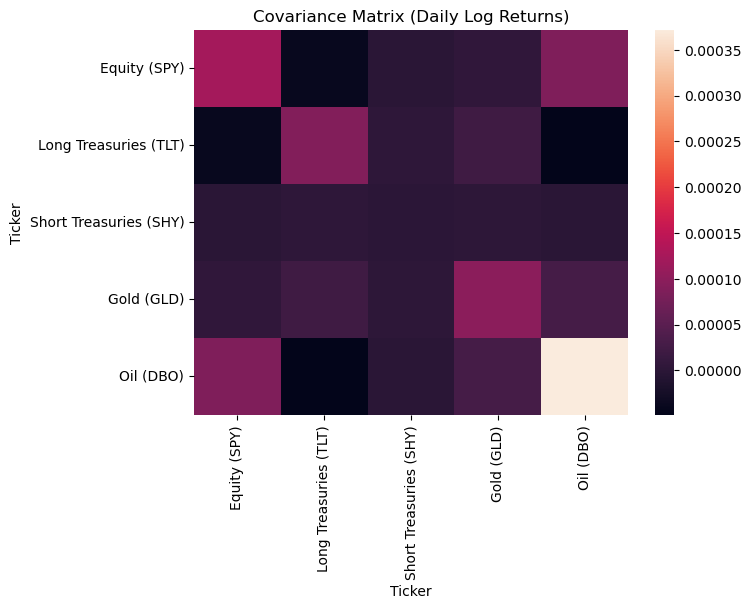

In [26]:
corr = ret.corr()
cov  = ret.cov()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix (Daily Log Returns)")
plt.show()

plt.figure(figsize=(7,5))
sns.heatmap(cov, annot=False)
plt.title("Covariance Matrix (Daily Log Returns)")
plt.show()

EDA: Stationarity checks (ADF test) on returns

In [27]:
def adf_test(series, name=""):
    s = series.dropna()
    stat, pvalue, lags, nobs, crit, icbest = adfuller(s, autolag="AIC")
    return {
        "asset": name,
        "adf_stat": stat,
        "p_value": pvalue,
        "used_lags": lags,
        "nobs": nobs,
        "crit_1%": crit["1%"],
        "crit_5%": crit["5%"],
        "crit_10%": crit["10%"],
    }

adf_results = pd.DataFrame([adf_test(ret[c], c) for c in ret.columns])
adf_results

,asset,adf_stat,p_value,used_lags,nobs,crit_1%,crit_5%,crit_10%
0,Equity (SPY),-12.302599,7.392273e-23,26,3219,-3.432383,-2.862438,-2.567248
1,Long Treasuries (TLT),-10.309772,3.208062e-18,24,3221,-3.432382,-2.862438,-2.567248
2,Short Treasuries (SHY),-10.740524,2.825870e-19,19,3226,-3.432379,-2.862436,-2.567247
3,Gold (GLD),-57.398269,0.000000e+00,0,3245,-3.432367,-2.862431,-2.567244
4,Oil (DBO),-59.999472,0.000000e+00,0,3245,-3.432367,-2.862431,-2.567244


EDA: Simple “seasonality” views (day-of-week + monthly heatmap)

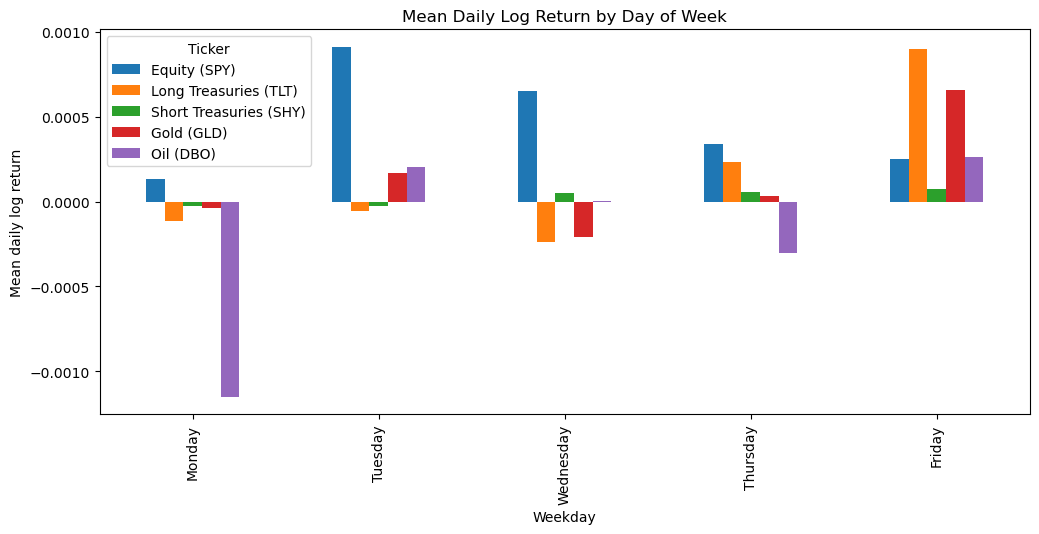

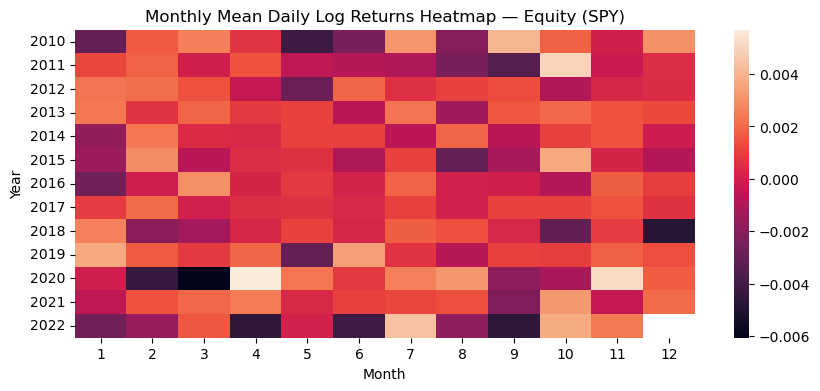

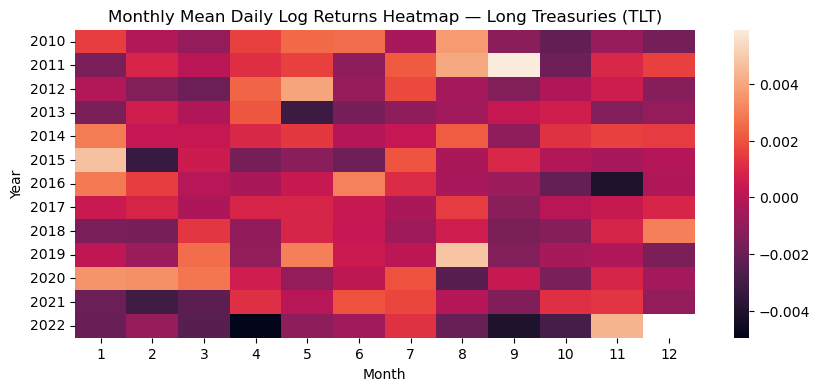

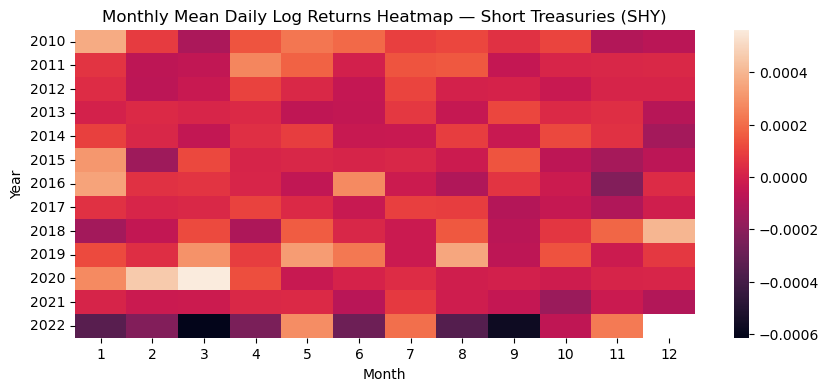

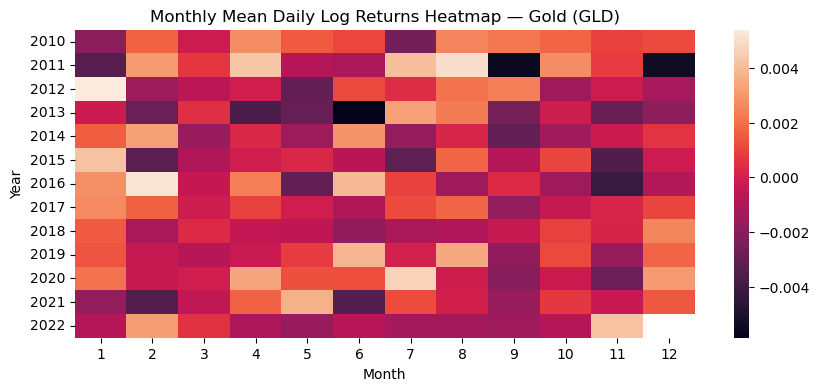

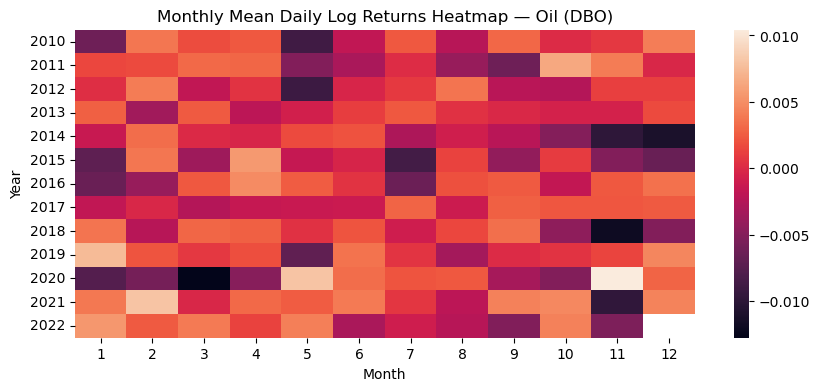

In [28]:
# Day-of-week effect (mean daily log return by weekday)
dow = ret.copy()
dow["weekday"] = dow.index.day_name()
dow_mean = dow.groupby("weekday").mean().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday"]
)

dow_mean.plot(kind="bar", figsize=(12,5))
plt.title("Mean Daily Log Return by Day of Week")
plt.xlabel("Weekday")
plt.ylabel("Mean daily log return")
plt.show()

# Monthly heatmap of mean daily returns
monthly = ret.copy()
monthly["year"] = monthly.index.year
monthly["month"] = monthly.index.month

monthly_mean = monthly.groupby(["year","month"]).mean()

for col in ret.columns:
    pivot = monthly_mean[col].unstack("month")
    plt.figure(figsize=(10,4))
    sns.heatmap(pivot, annot=False)
    plt.title(f"Monthly Mean Daily Log Returns Heatmap — {col}")
    plt.xlabel("Month")
    plt.ylabel("Year")
    plt.show()

In [ ]:
summary_stats(fwd_25d)